In [169]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
import seaborn as sns 
from pathlib import Path 
from scipy.sparse.linalg import svds
warnings.filterwarnings('ignore')

# Engenharia de dados

 - Inicialmente vamos extrair os dados de filmes, capturando todas as informações disponiveis para realizar uma analise explorátoria simples desses dados.

In [170]:
nb_dir = Path.cwd().parent
data_dir_movie = nb_dir / "data/Movies"


In [171]:
df_ratings = pd.read_csv(data_dir_movie / 'ratings.csv')
df_movies = pd.read_csv(data_dir_movie / 'movies.csv')
df_tags = pd.read_csv(data_dir_movie / 'tags.csv')
df_links = pd.read_csv(data_dir_movie / 'links.csv')

# Analise explorátoria

 - Vamos fazer alguns entendimentos:
    - **Curiosidades da base**
    - **Missing - Dados nulos**
    - **Dados duplicados**
    - **Distribuição das variaveis**


## Objetivo:

- Para fazermos uma analise explorátoria antes vou definir qual é nosso objetivo.
    - Como o objetivo desse desafio acadêmico seria utilização da técnica SVD (Singular Value Decomposition), vamos focar na df_rating, que é a tabela que tem como sua composição os dados númericos de notas para utilizarmos a técnica.
    - Como essa técnica tem algumas finalidades, vamos focar em criar uma forma de recomendação dos nosso filmes para os clientes.


### Curiosidades


In [172]:
df_ratings['tempo'] = pd.to_datetime(df_ratings['timestamp'],unit='s')

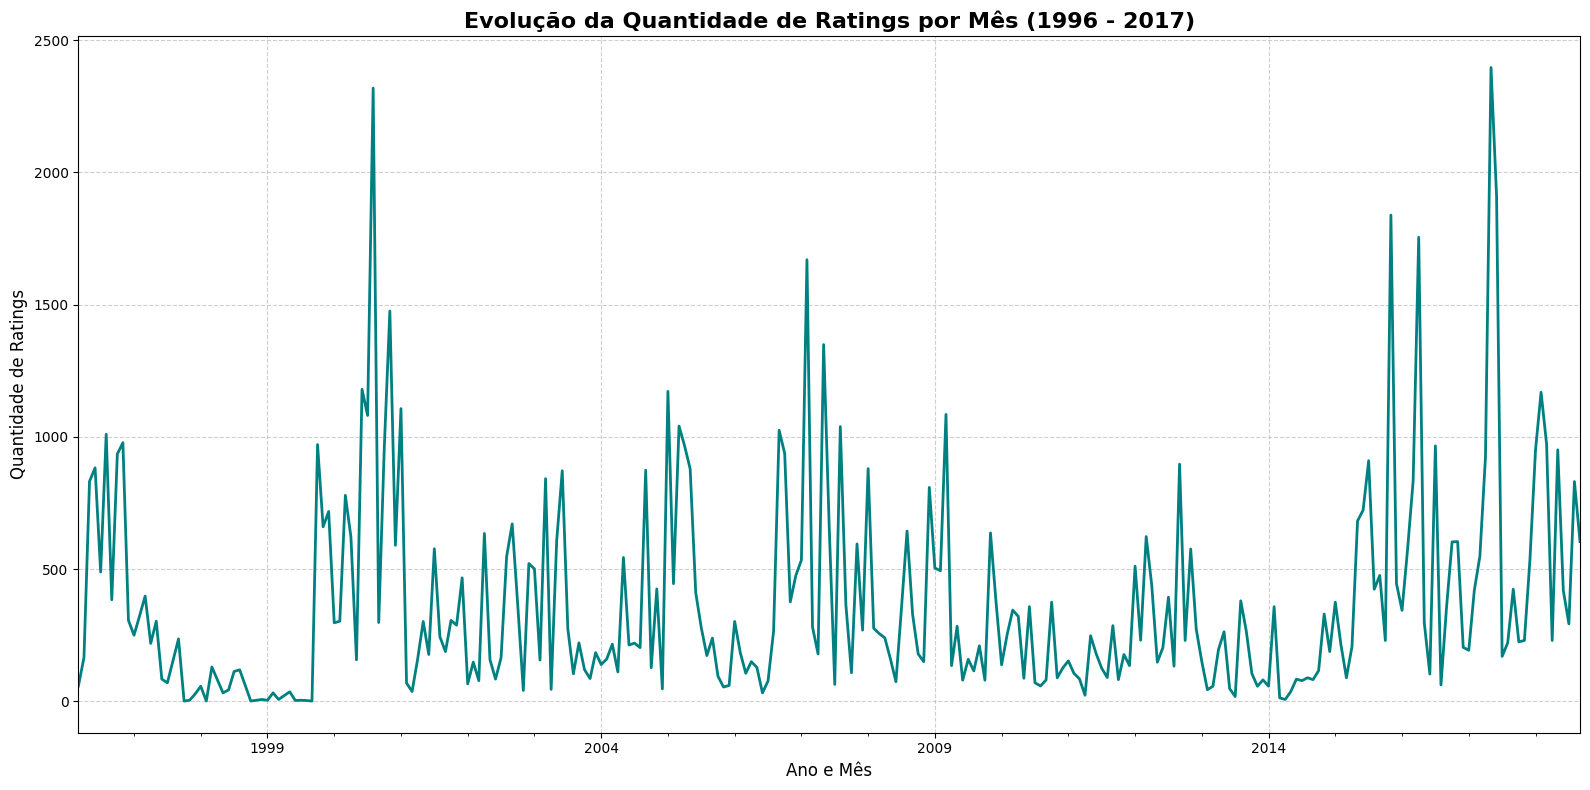

In [173]:
df_ratings['ano_mes'] = df_ratings['tempo'].dt.to_period('M')
# df_ratings_copy = df_ratings[df_ratings['ano_mes']>='2017-01']
contagem_mensal = df_ratings.groupby('ano_mes').size()

plt.figure(figsize=(16, 8)) # Define o tamanho do gráfico (largura, altura)

contagem_mensal.plot(kind='line', color='teal', linewidth=2)
 
plt.title('Evolução da Quantidade de Ratings por Mês (1996 - 2017)', fontsize=16, fontweight='bold')
plt.xlabel('Ano e Mês', fontsize=12)
plt.ylabel('Quantidade de Ratings', fontsize=12)
 
plt.grid(True, linestyle='--', alpha=0.6)
 
plt.tight_layout()
 
plt.show()

In [174]:
top_5_meses = contagem_mensal.nlargest(20).reset_index()
listagem = top_5_meses['ano_mes'].astype(str).tolist()
df_ratings[df_ratings['ano_mes'].astype(str).isin(listagem)].groupby('ano_mes').agg(
    qtd_usuarios = ('userId', 'nunique'),
    qtd_filmes = ('movieId', 'nunique'),
    qtd_registros_base = ('userId', 'count')
).reset_index().sort_values('qtd_registros_base',ascending=False )

,ano_mes,qtd_usuarios,qtd_filmes,qtd_registros_base
17,2017-05,12,1700,2397
5,2000-08,15,1336,2319
18,2017-06,9,1757,1910
15,2015-11,17,1161,1839
16,2016-04,12,1103,1755
11,2007-02,11,1506,1670
6,2000-11,18,893,1476
12,2007-05,15,1007,1349
3,2000-06,7,1070,1180
8,2005-01,14,882,1172


In [175]:
filmes_com_mais_avaliacao = df_ratings.groupby('movieId').size().sort_values(ascending=False)
top_10_filmes = df_ratings.groupby('movieId').size().nlargest(10).reset_index().rename(columns={0:'Qtd_avaliacoes'})
top_10_filmes.merge(df_movies[['movieId','title','genres']],how='inner',on='movieId')

,movieId,Qtd_avaliacoes,title,genres
0,356,329,Forrest Gump (1994),Comedy|Drama|Romance|War
1,318,317,"Shawshank Redemption, The (1994)",Crime|Drama
2,296,307,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
3,593,279,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
4,2571,278,"Matrix, The (1999)",Action|Sci-Fi|Thriller
5,260,251,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
6,480,238,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
7,110,237,Braveheart (1995),Action|Drama|War
8,589,224,Terminator 2: Judgment Day (1991),Action|Sci-Fi
9,527,220,Schindler's List (1993),Drama|War


In [176]:
df_tags['tempo'] = pd.to_datetime(df_tags['timestamp'],unit='s')
df_tags.groupby('tag').size().sort_values(ascending=False).nlargest(10).reset_index()

,tag,0
0,In Netflix queue,131
1,atmospheric,36
2,thought-provoking,24
3,superhero,24
4,Disney,23
5,surreal,23
6,funny,23
7,religion,22
8,dark comedy,21
9,sci-fi,21


#### Conclusão - Curiosidades
A base contém notas do periodo de 1996 a 2017. \
Como pudemos notar temos o periodo como 2017-07 e 2017-06 com maiores quantidade de registros de notas em filmes, pois são os periodos com maior números de filmes diversos. \
Fizemos também uma análise de filmes com maiores avaliações e temos o clássico dos filmes o "Forrest Gump" e temos também filmes como Matrix que marcaram uma geração. \
E analisamos também as tags aplicadas pelos clientes, porém esperavámos algo mais chamativo e não foi correspondido, tendo como maior tag "está na fila da netflix". O que pudemos tirar disso foi a preferência de streamings de filmes dos clientes dos últimos anos segue sendo a netflix..

### Dados nulos

In [177]:
df_ratings.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
tempo        0
ano_mes      0
dtype: int64

### Dados duplicados

In [178]:
duplicados = df_ratings[df_ratings.duplicated]
duplicados

,userId,movieId,rating,timestamp,tempo,ano_mes


### Distribuição dos dados

In [179]:
df_ratings.dtypes

userId                int64
movieId               int64
rating              float64
timestamp             int64
tempo        datetime64[ns]
ano_mes           period[M]
dtype: object

rating
4.0    26818
3.0    20047
5.0    13211
3.5    13136
4.5     8551
2.0     7551
2.5     5550
1.0     2811
1.5     1791
0.5     1370
Name: count, dtype: int64
rating
4.0    0.265957
3.0    0.198808
5.0    0.131015
3.5    0.130271
4.5    0.084801
2.0    0.074884
2.5    0.055040
1.0    0.027877
1.5    0.017762
0.5    0.013586
Name: proportion, dtype: float64


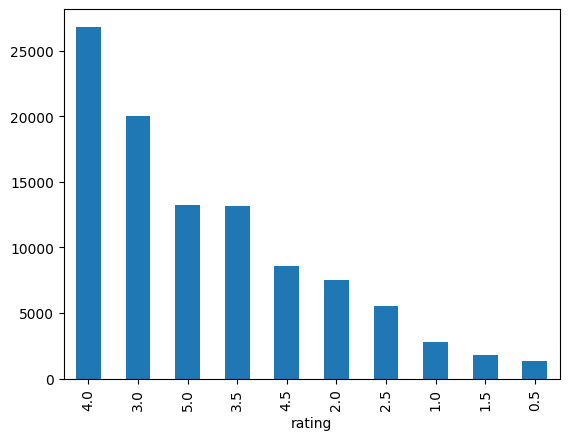

In [180]:
df_ratings['rating'].value_counts().plot(kind='bar')
print(df_ratings['rating'].value_counts())
print(df_ratings['rating'].value_counts(normalize=True))
plt.show()

<Axes: xlabel='rating'>

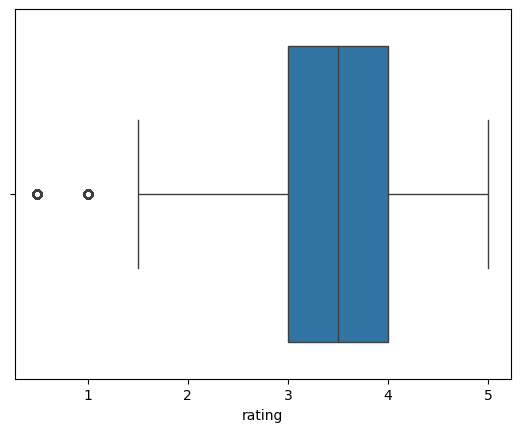

In [181]:
sns.boxplot(x=df_ratings['rating']) 